# Radiomic Baseline — Pipeline Comparison

446 pre-computed radiomic features (texture, shape, intensity; arterial + delayed phase).

| Experiment | SelectKBest | PCA | Model |
|------------|-------------|-----|-------|
| 1. Baseline (original) | — | 90% var | LR, RF |
| 2. SelectKBest + PCA | k | 90% var | LR, RF |
| 3. No PCA, low C | — | — | LR (L1, small C) |
| 4. SelectKBest, no PCA, low C | k | — | LR (L1, small C) |

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

from hcc_multimodal.baselines.config import RANDOM_STATE
from hcc_multimodal.baselines.transforms import DataType, build_preprocessor
from hcc_multimodal.baselines.evaluation import (
    plot_cv_results,
    plot_experiment_comparison,
)

In [2]:
# ── Configuration ──────────────────────────────────────────────
SELECT_K = 100
MAX_ITER = 5000
LR_C = 1.0
LR_C_SMALL = 0.1

## Load data

In [3]:
ROOT = Path().resolve().parents[1]

clinical_data = pd.read_csv(
    ROOT / "data" / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

radiomics_data = pd.read_csv(
    ROOT / "data" / "Radiomics" / "radiomic_cluster.csv"
).dropna(how="all")

# Extract targets
radiomic_death = radiomics_data[["SID", "death"]].copy()

# Radiomic features (first 447 columns = SID + 446 features)
radiomic_features = radiomics_data.iloc[:, :447]
radiomic_cols = [c for c in radiomic_features.columns if c != "SID"]
radiomic_x_columns = {col: DataType.CONTINUOUS for col in radiomic_cols}

print(f"Radiomic features: {len(radiomic_cols)}")
print(f"Patients: {len(radiomic_features)}")

Radiomic features: 446
Patients: 60


In [4]:
# Prepare X/y for both targets
# Target: death
X_death = radiomic_features.set_index("SID")[radiomic_cols]
y_death = radiomic_death.set_index("SID")["death"]
common = X_death.index.intersection(y_death.index)
X_death = X_death.loc[common].reset_index(drop=True)
y_death = y_death.loc[common].reset_index(drop=True)

# Target: OS_central_event
rad_os = radiomic_features.merge(clinical_data[["SID", "OS_central_event"]], on="SID", how="inner")
X_os = rad_os[radiomic_cols].reset_index(drop=True)
y_os = rad_os["OS_central_event"].reset_index(drop=True)

print(f"Radiomic → death:             n={len(y_death.dropna())}, positives={int(y_death.dropna().sum())}")
print(f"Radiomic → OS_central_event:  n={len(y_os.dropna())}, positives={int(y_os.dropna().sum())}")

Radiomic → death:             n=60, positives=24
Radiomic → OS_central_event:  n=56, positives=21


In [5]:
def run_experiment(X, y, x_columns, label, models, select_k=None, use_pca=True, n_splits=3):
    """Run stratified k-fold CV with configurable pipeline."""
    preprocessor = build_preprocessor(x_columns)
    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    mask = ~y.isna()
    X_clean, y_clean = X[mask], y[mask]
    print(f"[{label}]  n={len(y_clean)}  positives={int(y_clean.sum())}  features={X_clean.shape[1]}")

    records, fold_records = [], []
    for model_name, model in models.items():
        steps = [("preprocessor", preprocessor)]
        if select_k is not None:
            steps.append(("select_k", SelectKBest(f_classif, k=select_k)))
        if use_pca:
            steps.append(("pca", PCA(n_components=0.9, random_state=RANDOM_STATE)))
        steps.append(("model", model))
        pipe = Pipeline(steps)

        scores = cross_validate(
            pipe, X_clean, y_clean, cv=outer_cv,
            scoring=["roc_auc", "accuracy"], return_train_score=True,
        )
        records.append({
            "experiment": label, "model": model_name,
            "AUC mean": round(scores["test_roc_auc"].mean(), 3),
            "AUC std": round(scores["test_roc_auc"].std(), 3),
            "Accuracy mean": round(scores["test_accuracy"].mean(), 3),
            "Accuracy std": round(scores["test_accuracy"].std(), 3),
        })
        for fold_i, (train_auc, test_auc) in enumerate(
            zip(scores["train_roc_auc"], scores["test_roc_auc"])
        ):
            fold_records.append({
                "experiment": label, "model": model_name,
                "fold": fold_i + 1, "train_auc": train_auc,
                "test_auc": test_auc, "best_params": {},
            })
    return pd.DataFrame(records), pd.DataFrame(fold_records)

In [6]:
models_default = {
    "LR": LogisticRegression(solver="saga", l1_ratio=1.0, C=LR_C, max_iter=MAX_ITER, random_state=RANDOM_STATE),
    "RF": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}
models_small_c = {
    "LR (small C)": LogisticRegression(solver="saga", l1_ratio=1.0, C=LR_C_SMALL, max_iter=MAX_ITER, random_state=RANDOM_STATE),
}

## Exp 1: No SelectKBest + PCA (original pipeline)

In [7]:
# Original pipeline results (from 0417_baselines.md) — no need to rerun
original = pd.DataFrame([
    {"experiment": "Radiomic → death (original)", "model": "LR", "AUC mean": 0.642, "AUC std": 0.069, "Accuracy mean": 0.700, "Accuracy std": 0.071},
    {"experiment": "Radiomic → death (original)", "model": "RF", "AUC mean": 0.670, "AUC std": 0.101, "Accuracy mean": 0.667, "Accuracy std": 0.024},
    {"experiment": "Radiomic → OS_central_event (original)", "model": "LR", "AUC mean": 0.359, "AUC std": 0.141, "Accuracy mean": 0.443, "Accuracy std": 0.125},
    {"experiment": "Radiomic → OS_central_event (original)", "model": "RF", "AUC mean": 0.441, "AUC std": 0.076, "Accuracy mean": 0.517, "Accuracy std": 0.055},
])
print("Exp 1: Original baseline (from 0417_baselines.md)")
print(original.to_string(index=False))

Exp 1: Original baseline (from 0417_baselines.md)
                            experiment model  AUC mean  AUC std  Accuracy mean  Accuracy std
           Radiomic → death (original)    LR     0.642    0.069          0.700         0.071
           Radiomic → death (original)    RF     0.670    0.101          0.667         0.024
Radiomic → OS_central_event (original)    LR     0.359    0.141          0.443         0.125
Radiomic → OS_central_event (original)    RF     0.441    0.076          0.517         0.055


## Exp 2: SelectKBest + PCA

[Radiomic+KBest(100) → death]  n=60  positives=24  features=446


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarnin

/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


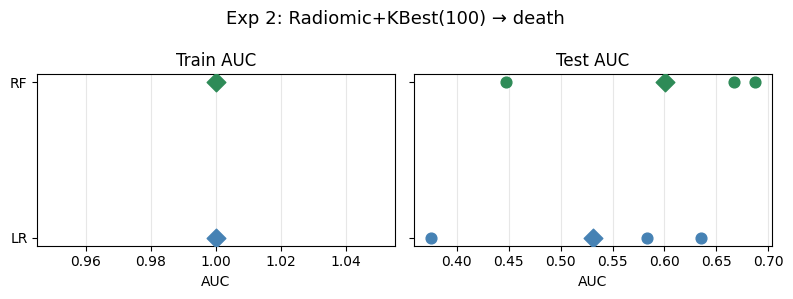

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic+KBest(100) → death,LR,0.531,0.113,0.617,0.094
1,Radiomic+KBest(100) → death,RF,0.601,0.108,0.633,0.024


In [8]:
cv_2a, fold_2a = run_experiment(
    X_death, y_death, radiomic_x_columns,
    label=f"Radiomic+KBest({SELECT_K}) → death",
    models=models_default, select_k=SELECT_K,
)
plot_cv_results(fold_2a, title=f"Exp 2: Radiomic+KBest({SELECT_K}) → death")
cv_2a

/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarnin

[Radiomic+KBest(100) → OS_central_event]  n=56  positives=21  features=446


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarnin

/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 115 116 132 146 153 157 172 189 204
 217 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395
 408 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


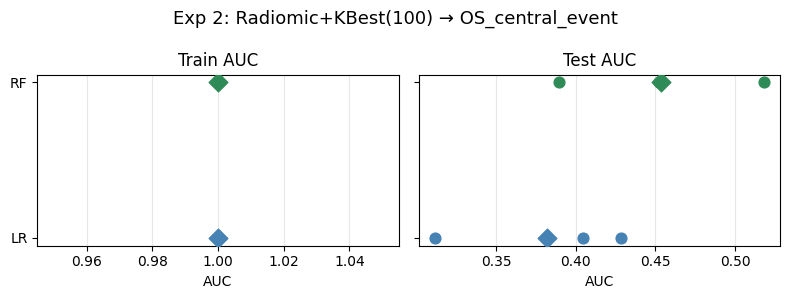

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic+KBest(100) → OS_central_event,LR,0.382,0.050,0.408,0.092
1,Radiomic+KBest(100) → OS_central_event,RF,0.453,0.052,0.481,0.034


In [9]:
cv_2b, fold_2b = run_experiment(
    X_os, y_os, radiomic_x_columns,
    label=f"Radiomic+KBest({SELECT_K}) → OS_central_event",
    models=models_default, select_k=SELECT_K,
)
plot_cv_results(fold_2b, title=f"Exp 2: Radiomic+KBest({SELECT_K}) → OS_central_event")
cv_2b

## Exp 3: No SelectKBest, no PCA, LR with small C

[Radiomic+L1(C=small) → death]  n=60  positives=24  features=446


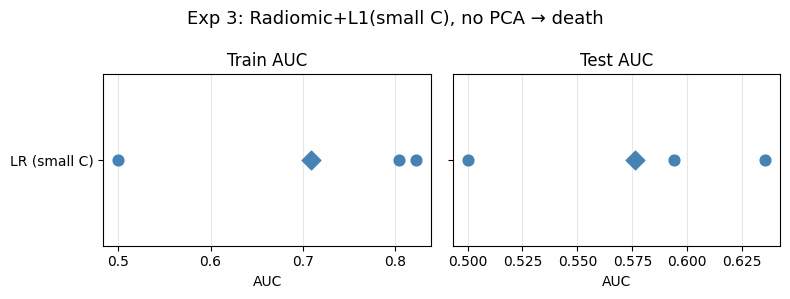

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic+L1(C=small) → death,LR (small C),0.576,0.057,0.6,0.0


In [10]:
cv_3a, fold_3a = run_experiment(
    X_death, y_death, radiomic_x_columns,
    label="Radiomic+L1(C=small) → death",
    models=models_small_c, use_pca=False,
)
plot_cv_results(fold_3a, title="Exp 3: Radiomic+L1(small C), no PCA → death")
cv_3a

[Radiomic+L1(C=small) → OS_central_event]  n=56  positives=21  features=446


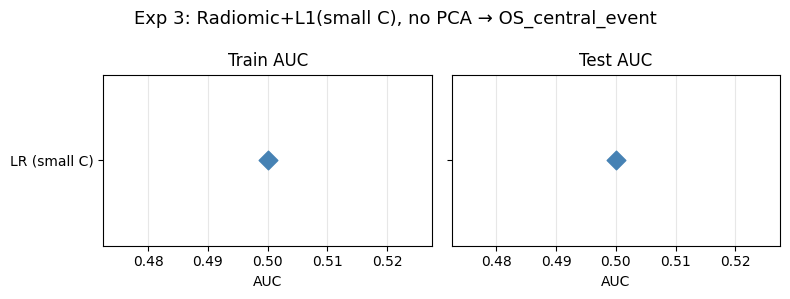

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic+L1(C=small) → OS_central_event,LR (small C),0.5,0.0,0.625,0.01


In [11]:
cv_3b, fold_3b = run_experiment(
    X_os, y_os, radiomic_x_columns,
    label="Radiomic+L1(C=small) → OS_central_event",
    models=models_small_c, use_pca=False,
)
plot_cv_results(fold_3b, title="Exp 3: Radiomic+L1(small C), no PCA → OS_central_event")
cv_3b

## Exp 4: SelectKBest, no PCA, LR with small C

[Radiomic+KBest(100)+L1(C=small) → death]  n=60  positives=24  features=446


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarnin

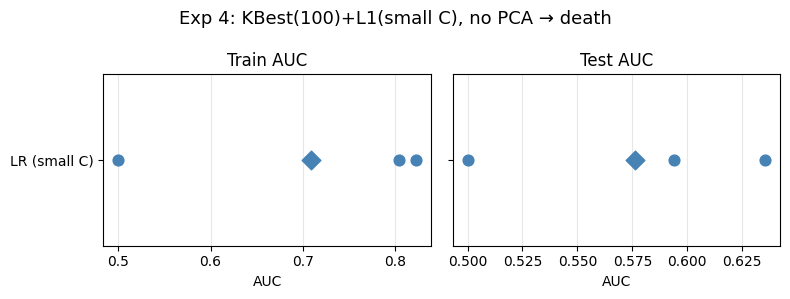

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic+KBest(100)+L1(C=small) → death,LR (small C),0.576,0.057,0.6,0.0


In [12]:
cv_4a, fold_4a = run_experiment(
    X_death, y_death, radiomic_x_columns,
    label=f"Radiomic+KBest({SELECT_K})+L1(C=small) → death",
    models=models_small_c, select_k=SELECT_K, use_pca=False,
)
plot_cv_results(fold_4a, title=f"Exp 4: KBest({SELECT_K})+L1(small C), no PCA → death")
cv_4a

[Radiomic+KBest(100)+L1(C=small) → OS_central_event]  n=56  positives=21  features=446


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  2   9  23  41  55  68  84 101 102 116 132 146 153 157 172 189 204 217
 234 243 244 261 262 280 296 304 310 327 346 358 359 370 384 394 395 408
 429 443] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarnin

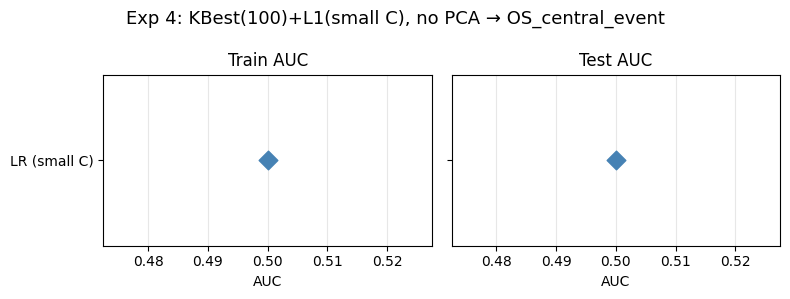

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic+KBest(100)+L1(C=small) → OS_central_e...,LR (small C),0.5,0.0,0.625,0.01


In [13]:
cv_4b, fold_4b = run_experiment(
    X_os, y_os, radiomic_x_columns,
    label=f"Radiomic+KBest({SELECT_K})+L1(C=small) → OS_central_event",
    models=models_small_c, select_k=SELECT_K, use_pca=False,
)
plot_cv_results(fold_4b, title=f"Exp 4: KBest({SELECT_K})+L1(small C), no PCA → OS_central_event")
cv_4b

## Summary

Config: SELECT_K=100, MAX_ITER=5000, LR_C=1.0, LR_C_SMALL=0.1

                                        experiment        model  AUC mean  AUC std  Accuracy mean  Accuracy std
                       Radiomic → death (original)           LR     0.642    0.069          0.700         0.071
                       Radiomic → death (original)           RF     0.670    0.101          0.667         0.024
            Radiomic → OS_central_event (original)           LR     0.359    0.141          0.443         0.125
            Radiomic → OS_central_event (original)           RF     0.441    0.076          0.517         0.055
                       Radiomic+KBest(100) → death           LR     0.531    0.113          0.617         0.094
                       Radiomic+KBest(100) → death           RF     0.601    0.108          0.633         0.024
            Radiomic+KBest(100) → OS_central_event           LR     0.382    0.050          0.408         0.092
            Radiomic+KBest(100) → OS_cent

/Users/amo/programData/hcc-multimodal/hcc_multimodal/baselines/evaluation.py:220: RuntimeWarning: Mean of empty slice
  aucs.mean(),
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/amo/programData/hcc-multimodal/hcc_multimodal/baselines/evaluation.py:220: RuntimeWarning: Mean of empty slice
  aucs.mean(),
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/amo/programData/hcc-multimodal/hcc_multimodal/baselines/evaluation.py:220: RuntimeWarning: Mean of empty slice
  aucs.mean(),
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/

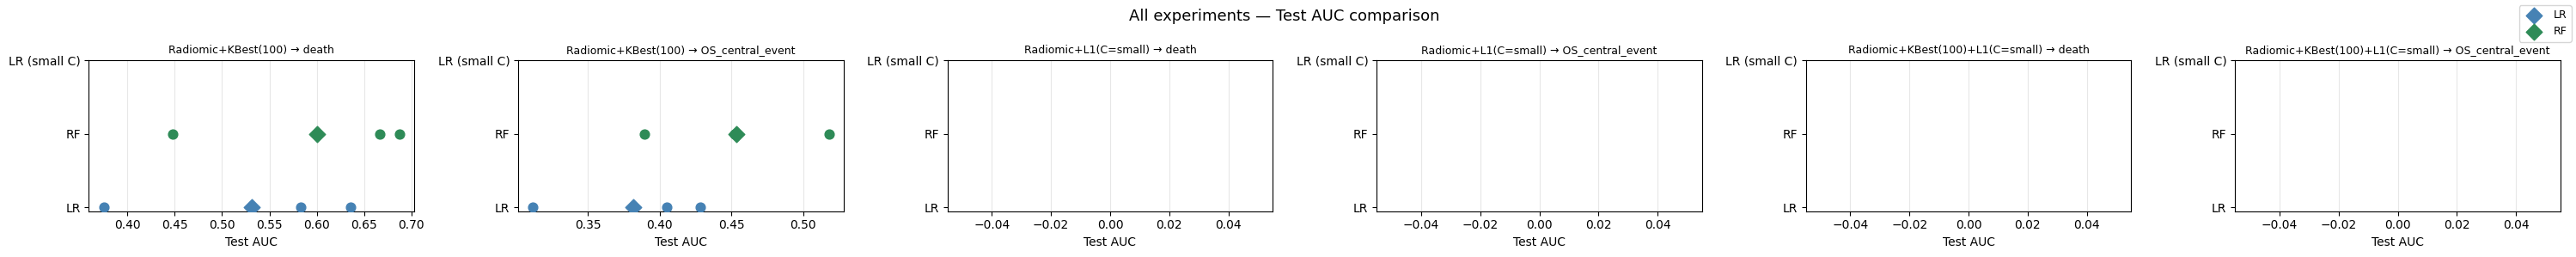

In [14]:
all_cv = pd.concat([original, cv_2a, cv_2b, cv_3a, cv_3b, cv_4a, cv_4b], ignore_index=True)
all_folds = pd.concat([fold_2a, fold_2b, fold_3a, fold_3b, fold_4a, fold_4b], ignore_index=True)

print(f"Config: SELECT_K={SELECT_K}, MAX_ITER={MAX_ITER}, LR_C={LR_C}, LR_C_SMALL={LR_C_SMALL}")
print()
print(all_cv.to_string(index=False))
plot_experiment_comparison(all_folds, title="All experiments — Test AUC comparison")